<a href="https://colab.research.google.com/github/guillevchar/EntregasCursoDeepLearning2026/blob/main/PRACTICA_02_GuillermoVicenteCharco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Guillermo Vicente Charco
guivicen@ucm.es

<font color="darkorange" size="10"><b>02. Trabajo con Python</b></font>

Miguel A. Castellanos

* Los entornos clásicos han hecho algún esfuerzo por adaptarse a esta tecnología pero la verdad es que se trabaja principalmente en un lenguaje llamado python
* Para poder trabajar eficientemente se necesita hardware específico (GPUS y otras arquitecturas que están apareciendo), en concreto las tarjetas Nvidia.
* Controlar directamente ese hardware es complejo, por eso se han desarrollado APIs (application programming interface)

\\

* Existen dos grandes sistemas para controlar esas GPUs: Tensorflow (google) y Pytorch (Facebook)
* Ambas utilizan python

\\

* Trabajar en Deep Learning directamente con tensorflow puede implicar programación matricial compleja
* Todo eso se puede simplificar usando APIS
* Las APIS son librerías de alto nivel como Keras o Pytorch que hacen la vida más fácil a todo el mundo
* El código estará escrito en python
* Explicaremos lo mínimo imprescindible y aceptaremos un cierto grado de “magia” en lo que estamos haciendo


## <font color="darkorange"><b>Básico de Colab</b></font>

- Colab es el servicio en la nube de Google que vamosa utilizar en este curso



* Vamos a trabajar con pytorch, usando herramientas para notebooks
basados en el entorno de colab: https://colab.research.google.com
* Podemos hacer de todo con colab pero hay poca potencia de cálculo
* La instalación en un ordenador del entorno necesario puede ser compleja pero el que quiera puede seguir las instrucciones en https://pytorch.org/get-started/locally/
* En general, todo esto funciona mejor si usas Linux

\\


* Para poder ejecutar python en Colab necesitamos una cuenta de google pero todas las cuentas UCM son cuentas de google así que no hay problema (usuario y contraseña de la UCM)


In [ ]:
# Este es nuestro primer codigo

print("hola mundo")


Este tipo de cuadernos que mezclan código con explicaciones son fundamentales en ciencia de datos (como jupyter) y son los más utilizado para aprender conceptos de ingeniería de datos.

Las celdas de texto se escriben en Markdown


## <font color="darkorange"><b>Conceptos necesarios de Python</b></font>

- Python es el lenguaje de la Ciencia de Datos y Deep Learning
- Partimos de un nivel razonable de programación en **R** y vemos qué cosas son diferentes





In [ ]:
# Operaciones básicas con python

# crear una variable
x = 10
y = x + 15 ** 3

# Mezclar texto con cadenas
print("El numero es: ", y)

# importar un paquete de python y usarlo
import random
z = random.randint(-10,10)
print(z)

In [ ]:
# Las estructuras de datos son diferentes

mi_lista = ["manzana", "platano", "pera"] # el más usado, ordenados y mutables
mi_tupla = ("manzana", "platano", "pera") # ordenados, inmutables
mi_set = {"manzana", "platano", "pera"} # (conjuntos) no ordenados, inmutables pero menos (se pueden quitar y añadir)
mi_dic = {
  "marca": "seat",
  "modelo": "ibiza",
  "year": 1964
} # no ordenados y mutables, son pares de key y value

# Los contadores empiezan en 0 y no en 1 como en R
print(mi_lista[0])
print(mi_tupla[1])

# Los más utilizados son las listas y los diccionarios, los otros dos (tupla y sets)
# Se utilizan en otros contextos


In [ ]:
# Las variables no ordenadas son confusas para acceder a ellos

# ejemplo para un conjunto (set)

# print(mi_set[0]) # da error porque no está ordenado

# pero se puede recorrer, fíjate en el for, no usa corchetes porque se usa la identación
for i in mi_set:
  print(i)


# Se puede accecer a los diccionarios con el nombre de la key
print(mi_dic["modelo"])

# Otra forma es pasar la variable a lista que si es ordenada y acceder con indices
print(list(mi_dic.keys())[1],":", list(mi_dic.values())[1])

In [ ]:
# Uso de for (imprescindible para Deep Learning)
# Ojo, solo para ordenados

for fruta in mi_lista:
  print(fruta)

In [ ]:
# Algo extremadamente util es el uso de print(f"") porque nos permite formatear
# outputs con mucha libertad, por ejemplo

nombre = "Paco"
print(f"Su nombre es {nombre}.")

name = 'Carla'
age = 22
print(f"Hello, My name is {name} and I'm {age} years old.")

width = 10
precision = 5
value = 12.34567
print(f"result: {value:{width}.{precision}}")


In [ ]:
# Crear un función

def greet (name):
  print("Hello, " + name + "!")

greet("miguel")



# Pueden devolver varios valores
def foo (v1, v2):
  return v1+1, v2+1, v1+v2

a, b, c = foo(2, 3)
print(a, b, c)

# Cuando solo se quiere recoger uno se puede utilizar '_'
_, b, _ = foo(2, 3)


In [ ]:
# Se utilizan mucho las clases
# Se busca encapsular todo, los datos y las funciones en un mismo objeto

class Person:

  def __init__(self, name, age): # __init__ es un método obligatorio, inicializa la clase
    self.name = name # cargamos variables en la clase
    self.age = age
  def animo (self): # Definimos una función
    print( f"{self.name}, eres un máquina!" )


p1 = Person("carlos", 36)

print(p1.name)
print(p1.age)

# Estamos usando la funcion de la clase
p1.animo()

In [ ]:
# Un iterable es un objeto que puede ser iterado (debe ser ordenado), pe: una lista

mi_lista = ["manzana", "platano", "pera"]

# Un iterador es un objeto que guarda la posición en el recorrido de un iterable
# Se controlan con iter y next
iterador = iter(mi_lista)

print(next(iterador))
print(next(iterador))
print(next(iterador))

# Algunos elementos de python incorporan automaticamente iteradores, por ejemplo,
# los bucles for

for elemento in mi_lista:
    print(elemento)

# Una función importante para recorrer objetos es enumerate, crea el iterador
# y lo usa a la vez

for indice, fruta in enumerate(mi_lista):
    print(f"Indice {indice}: {fruta}")




## <font color="darkorange"><b>Ejemplos para el uso de matplotlib</b></font>

- Matplotlib es la librería de python que se encarga de hacer gráficos, es muy sencilla de usar y también muy potente

In [ ]:
import matplotlib.pyplot as plt

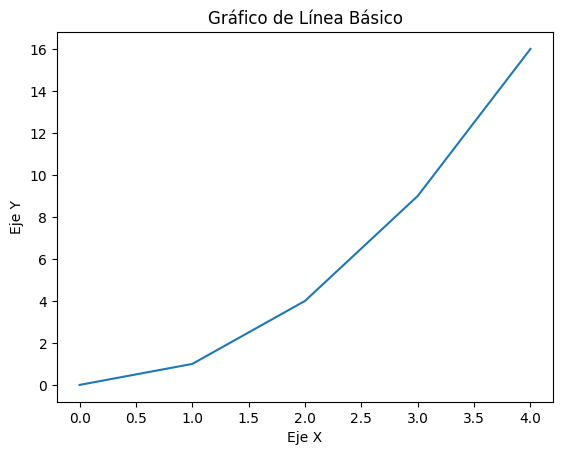

In [ ]:
# Un simple linea

# Datos
x = [0, 1, 2, 3, 4]
y = [0, 1, 4, 9, 16]

# Crear el gráfico
plt.plot(x, y)

# Etiquetas
plt.title("Gráfico de Línea Básico")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")

# Mostrar el gráfico
plt.show()

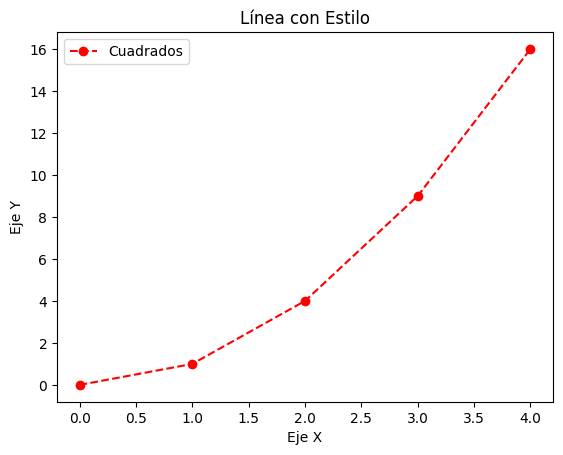

In [ ]:
# Una linea con estilo

# Datos
x = [0, 1, 2, 3, 4]
y = [0, 1, 4, 9, 16]

# Personalizar el estilo
plt.plot(x, y, color="red", linestyle="--", marker="o", label="Cuadrados")

# Agregar leyenda
plt.legend()

plt.title("Línea con Estilo")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.show()


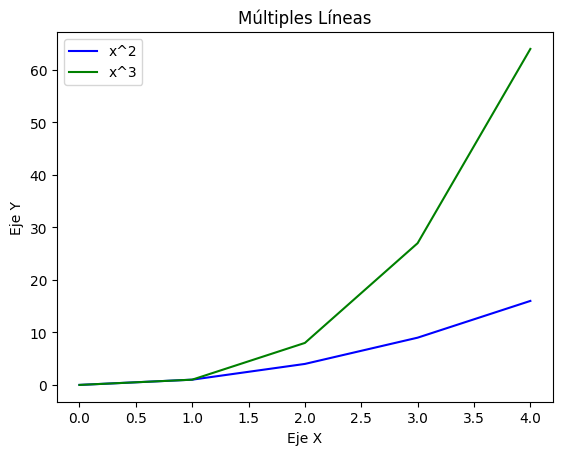

In [ ]:
# Dos lineas

# Datos
x = [0, 1, 2, 3, 4]
y1 = [0, 1, 4, 9, 16]
y2 = [0, 1, 8, 27, 64]

# Línea 1
plt.plot(x, y1, label="x^2", color="blue")

# Línea 2
plt.plot(x, y2, label="x^3", color="green")

# Personalización
plt.title("Múltiples Líneas")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.legend()

plt.show()


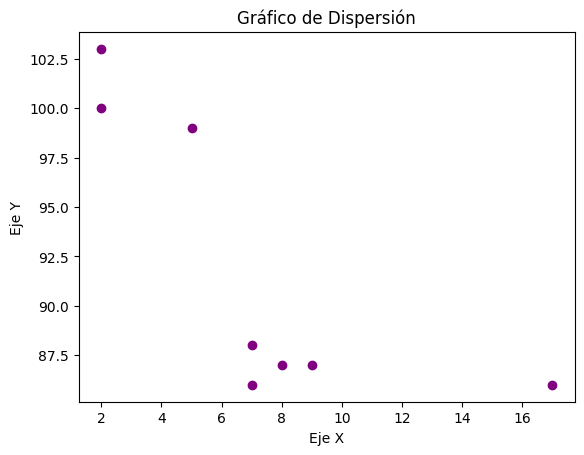

In [ ]:
# Gráfico de dispersión

# Datos
x = [5, 7, 8, 7, 2, 17, 2, 9]
y = [99, 86, 87, 88, 100, 86, 103, 87]

# Crear el gráfico
plt.scatter(x, y, color="purple")

plt.title("Gráfico de Dispersión")
plt.xlabel("Eje X")
plt.ylabel("Eje Y")
plt.show()


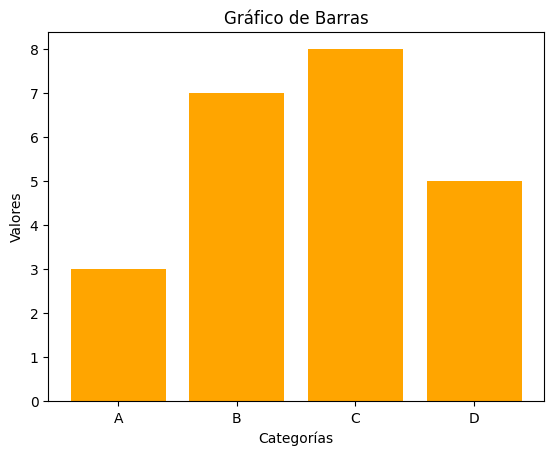

In [ ]:
# Gráfico de barras

# Datos
categorias = ["A", "B", "C", "D"]
valores = [3, 7, 8, 5]

# Crear el gráfico
plt.bar(categorias, valores, color="orange")

plt.title("Gráfico de Barras")
plt.xlabel("Categorías")
plt.ylabel("Valores")
plt.show()


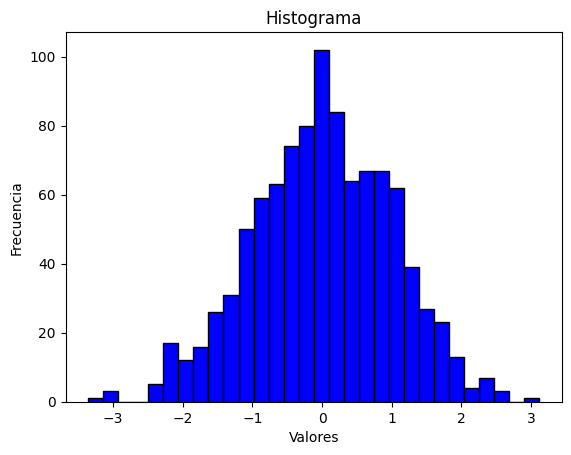

In [ ]:
# Un histograma

import numpy as np

# Datos aleatorios
datos = np.random.randn(1000)

# Crear el histograma
plt.hist(datos, bins=30, color="blue", edgecolor="black")

plt.title("Histograma")
plt.xlabel("Valores")
plt.ylabel("Frecuencia")
plt.show()


Text(0.5, 1.0, 'Figura 04')

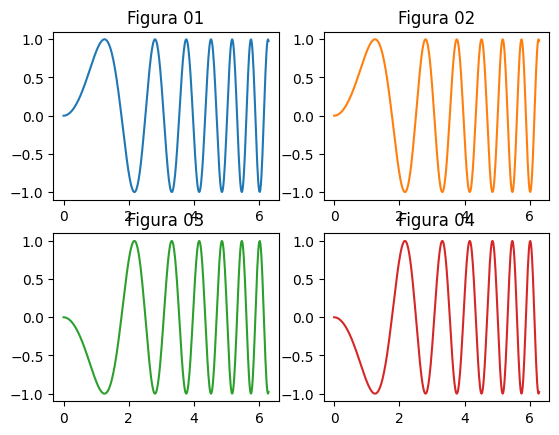

In [ ]:
# Crear subplots

# Some example data to display
x = np.linspace(0, 2 * np.pi, 400)
y = np.sin(x ** 2)

fig, axs = plt.subplots(2, 2)
axs[0, 0].plot(x, y)
axs[0, 0].set_title('Figura 01')

axs[0, 1].plot(x, y, 'tab:orange')
axs[0, 1].set_title('Figura 02')

axs[1, 0].plot(x, -y, 'tab:green')
axs[1, 0].set_title('Figura 03')

axs[1, 1].plot(x, -y, 'tab:red')
axs[1, 1].set_title('Figura 04')


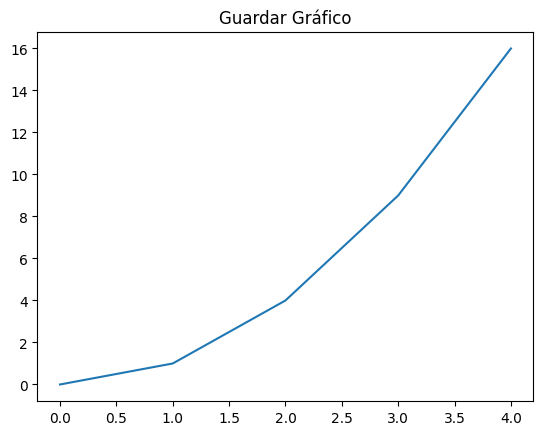

In [ ]:
# Guardar el grafico en un fichero

x = [0, 1, 2, 3, 4]
y = [0, 1, 4, 9, 16]

plt.plot(x, y)
plt.title("Guardar Gráfico")

# Guardar en formato PNG
plt.savefig("grafico.png")
plt.show()


## <font color="darkorange"><b>Uso básico de numpy</b></font>



- NumPy (Numerical Python) es una biblioteca fundamental para el cálculo numérico en Python. Su principal utilidad es trabajar con arrays n-dimensionales y realizar operaciones matemáticas de manera rápida y eficiente.


In [ ]:
# Una matriz puede ser una lista de listas
M = [
    [1,2,3],
    [4,5,6]
]
print(M[0][1])
print(M[:][1])

# Esto no se suele hacer, es pesado
# Las matrices se manejan con librerías específicas como numpy o pandas
# Lo vemos más adelante


In [ ]:
import numpy as np

# crear un vector a partir de una lista
mi_lista = [1, 2, 3, 4]
array = np.array(mi_lista)
print(array)          # Salida: [1 2 3 4]
print(type(array))

# Array 1D
array_1d = np.array([1, 2, 3])

# Array 2D
array_2d = np.array([[1, 2, 3], [4, 5, 6]])

# Array 3D
array_3d = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

print(array_1d)
print(array_2d)
print(array_3d)

# Array de ceros
ceros = np.zeros((2, 3))

# Array de unos
unos = np.ones((3, 3))

# Rango de números
rango = np.arange(0, 10, 2)  # Desde 0 hasta 10 (excluido) con paso 2



In [ ]:
# Operaciones con vectores y matrices

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Suma
print(a + b)  # Salida: [5 7 9]

# Resta
print(a - b)  # Salida: [-3 -3 -3]

# Multiplicación
print(a * b)  # Salida: [4 10 18]

# División
print(a / b)  # Salida: [0.25 0.4  0.5 ]


In [ ]:
# OJO: Hay dos tipos de multiplicaciones de matrices
# Las reales se hacen con matmul, estas son de arrays o byelement

a = np.array([[1, 2, 3], [4, 5, 6]]) # 2 x 3
b = np.array([[1], [2], [3]]) # 3 x 1

np.matmul(a, b)
# np.matmul(b, a) # No se puede hacer porque no casan las dimensiones



In [ ]:
# Acceso a los elementos

array = np.array([[1, 2, 3], [4, 5, 6]])

# Acceder al elemento en la fila 1, columna 2
print(array[1, 2])  # Salida: 6

# Acceder a una fila completa
print(array[0])  # Salida: [1 2 3]

# Subarray de la primera fila
print(array[0, 0:2])  # Salida: [1 2]

# Subarray de la primera columna
print(array[:, 0])  # Salida: [1 4]



In [ ]:
# Funciones sobre los arrays

array = np.array([1, 2, 3, 4])

# Raíz cuadrada
print(np.sqrt(array))  # Salida: [1. 1.414 1.732 2.]

# Seno
print(np.sin(array))  # Salida: [0.841 0.909 0.141 -0.757]

# Suma total
print(np.sum(array))  # Salida: 10


In [ ]:
# Generacion de numeros aleatorios

# Números aleatorios entre 0 y 1
aleatorios = np.random.rand(3, 3)

# Números enteros aleatorios
enteros = np.random.randint(0, 10, (2, 2))

print(aleatorios)
print(enteros)

In [ ]:
# Cambio de forma

array = np.array([[1, 2, 3], [4, 5, 6]])

# Cambiar forma a 3x2
reshaped = array.reshape((3, 2))

# Transponer
transpuesta = array.T

print(reshaped)
print(transpuesta)

## <font color="darkorange"><b>Tensores con pytorch</b></font>

* Un tensor es una estructura de datos que permiten operaciones matemáticas muy rápidas al ejecutarse en las GPUs.

En PyTorch, los tensores son estructuras clave, y la biblioteca los optimiza para funcionar eficientemente en CPU y GPU.

In [ ]:
import torch

# Lo habitual es crearlos a partir de datos de numpy

a = np.array([1, 2, 3])
t = torch.from_numpy(a)

In [ ]:
# También se pueden crear directamente con pytorch

# Crear un tensor desde una lista
tensor = torch.tensor([1, 2, 3, 4])
print(tensor)

# Tensor con forma 2x3
tensor_2d = torch.tensor([[1, 2, 3], [4, 5, 6]])
print(tensor_2d)

In [ ]:
# Tensor de ceros
ceros = torch.zeros((2, 3))  # Matriz 2x3 de ceros

# Tensor de unos
unos = torch.ones((3, 3))    # Matriz 3x3 de unos

# Tensor aleatorio entre 0 y 1
aleatorio = torch.rand((2, 2))

# Tensor vacío (valores no inicializados)
vacio = torch.empty((2, 2))

print(ceros, unos, aleatorio, vacio, sep="\n")

In [ ]:
tensor = torch.tensor([[1, 2, 3], [4, 5, 6]])

# Forma del tensor
print(tensor.shape)  # Salida: torch.Size([2, 3])

# Número de dimensiones
print(tensor.ndimension())  # Salida: 2

# Tipo de datos
print(tensor.dtype)  # Salida: torch.int64 (por defecto)

In [ ]:
a = torch.tensor([1, 2, 3])
b = torch.tensor([4, 5, 6])

# Suma
print(a + b)  # Salida: tensor([5, 7, 9])

# Resta
print(a - b)  # Salida: tensor([-3, -3, -3])

# Multiplicación elemento a elemento
print(a * b)  # Salida: tensor([4, 10, 18])

# División
print(a / b)  # Salida: tensor([0.2500, 0.4000, 0.5000])

In [ ]:
tensor = torch.tensor([[1, 2, 3], [4, 5, 6]])

# Acceder a un elemento
print(tensor[1, 2])  # Salida: tensor(6)

# Acceder a una fila completa
print(tensor[0])  # Salida: tensor([1, 2, 3])

# Slicing (sub-tensor)
print(tensor[:, 1])  # Salida: tensor([2, 5])

In [ ]:
# Se pueden calcular derivadas facilmente

import torch
import matplotlib.pyplot as plt
import numpy as np

# Crear valores para x como tensor de PyTorch
x = torch.linspace(-10, 10, 100, requires_grad=True)

# Definir la función: y = x^3 - 5x^2 + 10
y = x**3 - 5 * x**2 + 10

# Calcular la derivada de y con respecto a x
y.backward(torch.ones_like(x))  # Necesitamos un gradiente de entrada para tensores no escalares

# Extraer los valores para graficar
x_vals = x.detach().numpy()
y_vals = y.detach().numpy()
dy_dx_vals = x.grad.detach().numpy()  # Gradiente calculado por PyTorch

# Graficar la función y su derivada
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label="$y = x^3 - 5x^2 + 10$", color="blue")
plt.plot(x_vals, dy_dx_vals, label="Derivada $dy/dx$", color="red", linestyle="--")
plt.legend()
plt.grid(True)
plt.show()


## <font color="darkorange"><b>Otras utilidades</b></font>

In [ ]:
# Lo interesante de haber convertido una matriz en un tensor es que ahora puedo ejecutar las acciones directamente sobre la GPU

# Comprobamos si tenemos GPU
print(torch.cuda.is_available())  # Salida: True si hay una GPU disponible

# setting device on GPU if available, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

# Si tentemos cuda ponemos imprimir informacion
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print('Memory Usage:')
    print('Allocated:', round(torch.cuda.memory_allocated(0)/1024**3,1), 'GB')
    print('Cached:   ', round(torch.cuda.memory_reserved(0)/1024**3,1), 'GB')

# almacenamos los tensores en la GPU

if torch.cuda.is_available():
    tensor = torch.tensor([1, 2, 3], device='cuda')  # Crear tensor en GPU
    print(tensor)  # Salida: tensor([1, 2, 3], device='cuda:0')

    # Mover un tensor existente en la CPU a la GPU
    tensor_cpu = torch.tensor([4, 5, 6])
    tensor_gpu = tensor_cpu.to('cuda')
    print(tensor_gpu)

In [ ]:
if device.type == 'cuda':
  !nvidia-smi

## <font color="darkorange"><b>Ejercicios</b></font>

1. Crea un diccionario con ls siguitene información de tu vida (edad, sexo, estudios, nombre_amigos) [ojo, *nombre_amigos* será una lista con varios nombres]

1. Crea una función que imprima el diccionario anterior
1. Crea una clase que reciba como entrada el diccionario y lo imprima
1. Crea una lista de diccionarios con distintas personas como clase
1. Imprime la lista anterior con un for()
1. Genera con Matplotlib una variable X que vaya desde -3 hasta + 3 con la separación que quieras (tics)
1. Genera una variable Y que sea una distribución normal(0, 1)
1. Haz un gráfico con matplotlib de dicha distribución normal
1. Crea un vector que vaya de 0 a 10, conviértelo en una matriz de 2x5, multiplícalo por una matriz de unos y el resultado conviértelo en un tensor.
1. Calcula la derivada de x**3-2*x y dibuja ambas

## Ejercicio 1

In [ ]:
#Crea un diccionario con ls siguitene información de tu vida (edad, sexo, estudios, nombre_amigos) [ojo, nombre_amigos será una lista con varios nombres]

diccionario_persona = {
    'edad' : 22,
    'sexo' : 'H',
    'estudios' : 'Grado',
    'nombre_amigos' : ['Paco', 'Sara', 'Juan', 'Claudia']
}

## Ejercicio 2

In [ ]:
#Crea una función que imprima el diccionario anterior

print(diccionario_persona)

{'edad': 22, 'sexo': 'H', 'estudios': 'Grado', 'nombre_amigos': ['Paco', 'Sara', 'Juan', 'Claudia']}


## Ejercicio 3

In [ ]:
#Crea una clase que reciba como entrada el diccionario y lo imprima

class Persona:
    def __init__(self, edad, sexo, estuidos, nombre_amigos):
        self.edad = edad
        self.sexo = sexo
        self.estudios = estuidos
        self.nombre_amigos = nombre_amigos

    def imprimir_datos(self):
        print (f'Edad: {self.edad}')
        print (f'Sexo: {self.sexo}')
        print (f'Estudios: {self.estudios}')
        print (f'Amigos: {self.nombre_amigos}')

guille = Persona(diccionario_persona['edad'], diccionario_persona['sexo'], diccionario_persona['estudios'], diccionario_persona['nombre_amigos'])
guille.imprimir_datos()


Edad: 22
Sexo: H
Estudios: Grado
Amigos: ['Paco', 'Sara', 'Juan', 'Claudia']


## Ejercicio 4

In [ ]:
#Crea una lista de diccionarios con distintas personas como clase

juan = {
    'edad' : 15,
    'sexo' : 'H',
    'estudios' : 'ESO',
    'nombre_amigos' : ['Paco', 'Sara']
}
clara = {
    'edad' : 33,
    'sexo' : 'M',
    'estudios' : 'Postgrado',
    'nombre_amigos' : ['Jorge', 'Herminio']
}
kike = {
    'edad' : 22,
    'sexo' : 'H',
    'estudios' : 'FP',
    'nombre_amigos' : ['Ana', 'Pablo']
}

personas = [juan, clara, kike]

## Ejercicio 5

In [ ]:
#Imprime la lista anterior con un for()

for i in personas:
  p = Persona(i['edad'], i['sexo'], i['estudios'], i['nombre_amigos'])
  p.imprimir_datos()



Edad: 15
Sexo: H
Estudios: ESO
Amigos: ['Paco', 'Sara']
Edad: 33
Sexo: M
Estudios: Postgrado
Amigos: ['Jorge', 'Herminio']
Edad: 22
Sexo: H
Estudios: FP
Amigos: ['Ana', 'Pablo']


## Ejercicio 6

In [ ]:
#Genera con Matplotlib una variable X que vaya desde -3 hasta + 3 con la separación que quieras (tics)

# Si he entendido bin el objetivo, creo que se hace con Numpy, no con matplotlib
import numpy as np

X = np.arange(-3, 3, 0.5)

print(X)

[-3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2.   2.5]


## Ejercicio 7

In [ ]:
#Genera una variable Y que sea una distribución normal(0, 1)

Y = np.random.normal( 0, 1, 1000)
Y.sort()

print(Y)

[-2.84209399e+00 -2.79585148e+00 -2.70743121e+00 -2.70685541e+00
 -2.66682791e+00 -2.60689127e+00 -2.57430223e+00 -2.52078364e+00
 -2.48530705e+00 -2.44939195e+00 -2.44340704e+00 -2.41673706e+00
 -2.24939457e+00 -2.24612920e+00 -2.22070151e+00 -2.16767231e+00
 -2.14275363e+00 -2.12331078e+00 -2.11501167e+00 -2.03228440e+00
 -2.02441641e+00 -2.02181503e+00 -2.01816827e+00 -1.99657558e+00
 -1.97657450e+00 -1.97042257e+00 -1.95909974e+00 -1.94024902e+00
 -1.93732170e+00 -1.92704392e+00 -1.89807788e+00 -1.89105992e+00
 -1.88384039e+00 -1.87752940e+00 -1.86812210e+00 -1.86070187e+00
 -1.85048473e+00 -1.83763697e+00 -1.83652628e+00 -1.83267168e+00
 -1.79712231e+00 -1.79494144e+00 -1.78655589e+00 -1.77155457e+00
 -1.76093860e+00 -1.73255618e+00 -1.73123910e+00 -1.72144376e+00
 -1.71312264e+00 -1.71165316e+00 -1.69133481e+00 -1.67048713e+00
 -1.66868678e+00 -1.64048686e+00 -1.63650045e+00 -1.62873302e+00
 -1.62791685e+00 -1.61678134e+00 -1.59994351e+00 -1.57683495e+00
 -1.57211190e+00 -1.57086

## Ejercicio 8

(array([  9.,  42., 107., 185., 238., 197., 143.,  52.,  22.,   5.]),
 array([-2.84018393, -2.25237549, -1.66456705, -1.07675861, -0.48895017,
         0.09885827,  0.68666671,  1.27447515,  1.86228359,  2.45009203,
         3.03790047]),
 <BarContainer object of 10 artists>)

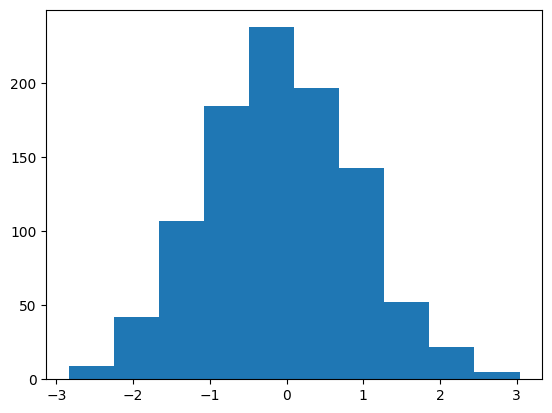

In [ ]:
#Haz un gráfico con matplotlib de dicha distribución normal
import matplotlib.pyplot as plt

# Empleamos un histograma para que se vea bien la distribución normal
plt.hist(Y)

## Ejercicio 9

In [ ]:
#Crea un vector que vaya de 0 a 10, conviértelo en una matriz de 2x5, multiplícalo
#por una matriz de unos y el resultado conviértelo en un tensor.
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print()

#Estoy usando la cpu en este caso

vector = np.arange(0,10); print(vector)
matriz = np.reshape(vector, (2,5)); print(matriz)
tensor = torch.tensor(matriz, device='cpu'); print(tensor)

Using device: cpu

[0 1 2 3 4 5 6 7 8 9]
[[0 1 2 3 4]
 [5 6 7 8 9]]
tensor([[0, 1, 2, 3, 4],
        [5, 6, 7, 8, 9]])


## Ejercicio 10

Coeficientes: [1, 0, -2, 0], Coeficiente derivados: [ 3  0 -2]
[-3.  -2.5 -2.  -1.5 -1.  -0.5  0.   0.5  1.   1.5  2.   2.5]
Datos: [-21.    -10.625  -4.     -0.375   1.      0.875   0.     -0.875  -1.
   0.375   4.     10.625], Datos derivados: [25.   16.75 10.    4.75  1.   -1.25 -2.   -1.25  1.    4.75 10.   16.75]


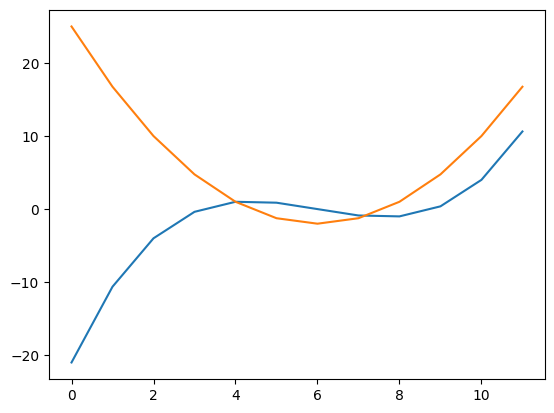

In [ ]:
#Calcula la derivada de x*3-2x y dibuja ambas

# Guardamos en variables los coeficientes y los coeficientes de la derivada
coef = [1, 0, -2, 0]
coef_deriv = np.polyder([1, 0, -2, 0])
print(f'Coeficientes: {coef}, Coeficiente derivados: {coef_deriv}')

# Generamos una lista de números para que nos sirvan como eje x en la función
x = np.arange(-3,3,0.5)

# Aplicamos las funciones al eje x para obtener su valor en el eje y
datos = np.polyval(coef, x)
datos_derivados = np.polyval(coef_deriv, x)
print(f'Datos: {datos}, Datos derivados: {datos_derivados}')

# Hacemos la gráfica
plt.plot(datos)
plt.plot(datos_derivados)